# Demo: Fault Simulation and Analysis

This notebook shows basic I/O operations that can be performed with fmdtools, as well as some of the basic model and simulation visualization and analysis features.

This is helpful for understanding the breadth of fmdtools plotting, tabulation, and visualization capabilities. Specifically, it covers:
  
  - A variety of graphing use-cases in {py:mod}`~fmdtools.analyze.graph` functions which enable viewing different graph types, simulation results at individual times, and overall model statistics/results.
  
  - {py:mod}`~fmdtools.analyze.tabulate` functions for viewing simulation results over time and summarizing run information.
  
  - Saving/Loading {py:class}`~fmdtools.analyze.result.Result` data structures.

This script runs these basic operations on the simple model defined in model_main.py.

```
Copyright © 2024, United States Government, as represented by the Administrator of the National Aeronautics and Space Administration. All rights reserved.

The “"Fault Model Design tools - fmdtools version 2"” software is licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
```


In [1]:
from model_main import Pump

import fmdtools.sim.propagate as propagate
from fmdtools import analyze as an

from IPython.display import HTML

### Initial Model Checks
Before seeing how faults propagate, it's useful to see that the model structure is set up correctly and that the system performs as expected.

The 'track' argument specifies what model attributes to log. Specifying `all` will log all attributes.

In [2]:
mdl = Pump(track='all')

One of the easiest ways to visualize this is by viewing the model in the repl, which shows thes states and modes of the component functions and flows.

In [3]:
mdl

pump Pump
- t=Time(time=-0.1, timers={})
- m=Mode(mode='nominal', faults=set(), sub_faults=False)
FLOWS:
- ee_1=Electricity(s=(current=1.0, voltage=1.0))
- sig_1=Signal(s=(power=1.0))
- wat_1=Water(s=(flowrate=1.0, pressure=1.0, area=1.0, level=1.0))
- wat_2=Water(s=(flowrate=1.0, pressure=1.0, area=1.0, level=1.0))
FXNS:
- import_ee=ImportEE(s=(effstate=1.0), m=(mode='nominal', faults=set(), sub_faults=False))
- import_water=ImportWater(m=(mode='nominal', faults=set(), sub_faults=False))
- import_signal=ImportSig(m=(mode='nominal', faults=set(), sub_faults=False))
- move_water=MoveWat(s=(eff=1.0), m=(mode='nominal', faults=set(), sub_faults=False))
- export_water=ExportWater(m=(mode='nominal', faults=set(), sub_faults=False))

#### Model Structure Visualization

To check that the simulation structures are set up right, the FunctionArchitectureGraph class lets us visualize the function/flow relationships in the model. This helps us answer the questions:
   - are all functions on the graph?
   - are the functions connected with the correct flows?

In [4]:
from fmdtools.define.architecture.function import FunctionArchitectureGraph

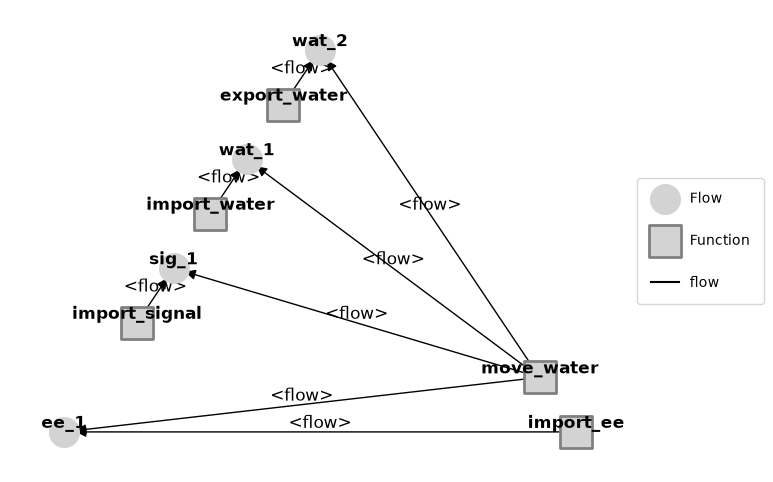

In [5]:
a = FunctionArchitectureGraph(mdl)
fig, ax = a.draw(figsize=(8,6))

Note that a variety of different Classes can be used for model structure visualization, inlcluding `ModelFxnGraph`, `ModelFlowGraph`, and `ModelTypeGraph`. This is further explained in `examples/navigating_rover/Model_Structure_Visualization_Tutorial.ipynb`

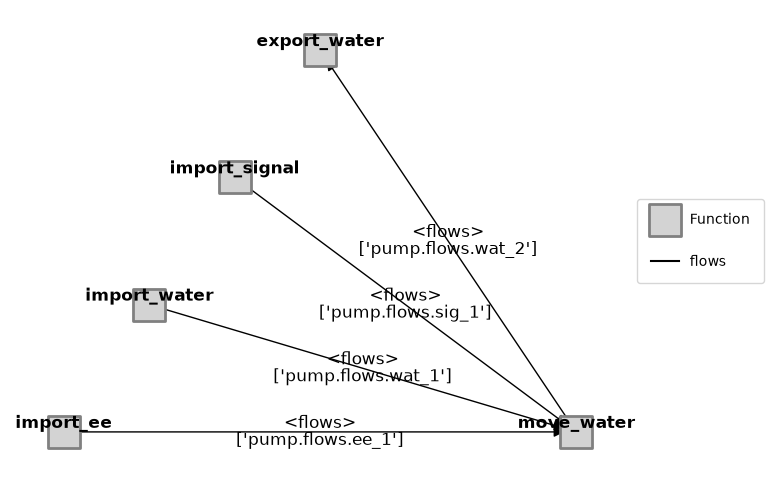

In [6]:
from fmdtools.define.architecture.function import FunctionArchitectureFxnGraph
b=FunctionArchitectureFxnGraph(mdl)
fig = b.draw(figsize=(8,6))

#### Nominal Run

The next code runs the model in the nominal state to check to see that the model has been defined correctly.
This helps us verify:
   - if any faults occur in the nominal scenario
   - if the progression of states proceeds as desired over time.

The following code runs the model with no faults to let us do that. The inputs are:
- mdl (the model we imported at the start of the script)
- to_return (str/list/dict describing what to return in result)
- **kwargs (see docs)

The outputs are:
- result (a `Result` object defined in `analyze.result`)
- mdlhist (a `History` object defined in `analyze.result`)

Both `Result` and `History` have a number of methods that can be readily used to process and analyze simulation results. See:
- [Result documentation](https://nasa.github.io/fmdtools/docs-source/fmdtools.analyze.html#fmdtools.analyze.result.Result)
- [History documentation](https://nasa.github.io/fmdtools/docs-source/fmdtools.analyze.html#fmdtools.analyze.result.History)

Many different properties can be requested given the `to_return` argument ([see full list here](https://nasa.github.io/fmdtools/docs-source/fmdtools.sim.html#fmdtools.sim.propagate.sim_kwargs)). In this case, we pass a dict with key `graph` and a value `FunctionArchitectureGraph` specifying that we want it to give us a graph view of the `Model`.

In [7]:
result, mdlhist = propagate.nominal(mdl, to_return={'graph': FunctionArchitectureGraph})

Here we can see where it is in the Result:

In [8]:
result.keys()

dict_keys(['tend.graph'])

In [9]:
graph = result.tend.graph

With these results, we can now plot the graph of results resgraph using:

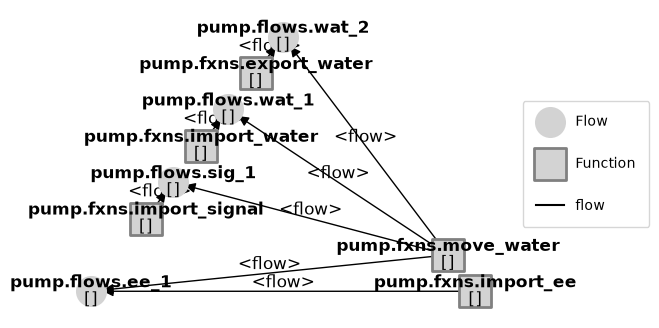

In [10]:
fig = graph.draw(figsize=(6,4))

As can be seen, this gives a graphical representation of the functional model with the various flows. Since all of the functions are *grey*, no faults were accidentally introduced in this run.


A model history is additionally returned given our specified tracking options. If none are provided, the `default_track` variable in the `Model` is used (which in this case is set to `all`). See below:

In [11]:
mdlhist

i.finished:                    array(56)
i.on:                          array(56)
m.sub_faults:                  array(56)
time:                          array(56)
flows.ee_1.s.current:          array(56)
flows.ee_1.s.voltage:          array(56)
flows.sig_1.s.power:           array(56)
flows.wat_1.s.flowrate:        array(56)
flows.wat_1.s.pressure:        array(56)
flows.wat_1.s.area:            array(56)
flows.wat_1.s.level:           array(56)
flows.wat_2.s.flowrate:        array(56)
flows.wat_2.s.pressure:        array(56)
flows.wat_2.s.area:            array(56)
flows.wat_2.s.level:           array(56)
fxns.import_ee.s.effstate:     array(56)
fxns.import_ee.m.faults.inf_v: array(56)
fxns.import_ee.m.faults.no_v:  array(56)
fxns.import_ee.m.sub_faults:   array(56)
fxns.import_water.m.faults.less_wat: array(56)
fxns.import_water.m.faults.no_wat: array(56)
fxns.import_water.m.sub_faults: array(56)
fxns.import_signal.m.faults.no_sig: array(56)
fxns.import_signal.m.sub_faults: array(56

We can further look at the states of the model over time using `History.plot_line`:

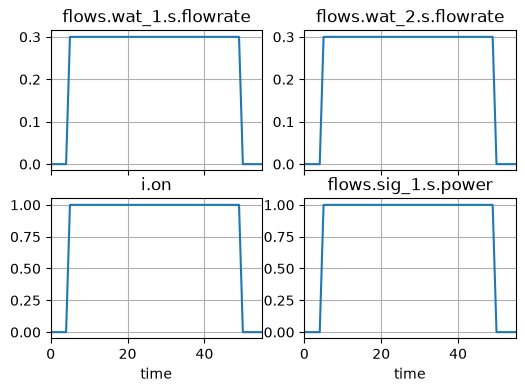

In [12]:
fig, ax = mdlhist.plot_line('flows.wat_1.s.flowrate', 'flows.wat_2.s.flowrate', 'i.on', 'flows.sig_1.s.power')

As we can see, the state of these flows does exactly what we would expect--when the switch turns on at $t=5$, the pump switches on and there is a flow of water in and out of the model.

### History
If we want to see this data in tabular form, we can use `fp.tabulate.hist()`:

In [13]:
nominal_histtable = mdlhist.as_table()
nominal_histtable[:10] #only displaying 10 

,i.finished,i.on,m.sub_faults,time,flows.ee_1.s.current,...,fxns.move_water.m.sub_faults,fxns.move_water.t.pressure_limit.time,fxns.move_water.t.pressure_limit.mode,fxns.export_water.m.faults.block,fxns.export_water.m.sub_faults
0,False,False,False,0.0,0.0,...,False,0.0,standby,False,False
1,False,False,False,1.0,0.0,...,False,0.0,standby,False,False
2,False,False,False,2.0,0.0,...,False,0.0,standby,False,False
3,False,False,False,3.0,0.0,...,False,0.0,standby,False,False
4,False,False,False,4.0,0.0,...,False,0.0,standby,False,False
5,False,True,False,5.0,10.0,...,False,0.0,standby,False,False
6,False,True,False,6.0,10.0,...,False,0.0,standby,False,False
7,False,True,False,7.0,10.0,...,False,0.0,standby,False,False
8,False,True,False,8.0,10.0,...,False,0.0,standby,False,False
9,False,True,False,9.0,10.0,...,False,0.0,standby,False,False


This table is a pandas dataframe. We can save this dataframe to a .csv using `nominal_histtable.to_csv("filename.csv")`

### Propagating and Viewing Results for Individual Faults
It is often necessary to see how the system reacts to individual faults. This can gives us better understanding of how the system behaves under individual faults and can let us iterate with the model better.

The following code runs the model with a single fault in a single function. In this case, we are initiating a short in the 'Move Water' function at 10 hours into the system's operation.

The inputs are:
- `mdl` (the model we imported at the start of the script)
- `function` (the function the fault we're interested in propagating occurs in)
- `faultmode` (the fault to initiate)
- `time` (the time when the fault is initiated)
- **kwargs )

The outputs are (the same as propogate.nominal):
- `results` (a dictionary corresponding to `to_return`)
- `mdlhist` (the states of the model over time)

In [14]:
endresults, mdlhist=propagate.one_fault(mdl, 'move_water', 'short', time=10, 
                                        to_return=['graph','classify','endfaults'])

Now mdlhist has double the number of entries--those corresponding to the nominal and faulty scenarios.

In [15]:
mdlhist

nominal.i.finished:            array(56)
nominal.i.on:                  array(56)
nominal.m.sub_faults:          array(56)
nominal.time:                  array(56)
nominal.flows.ee_1.s.current:  array(56)
nominal.flows.ee_1.s.voltage:  array(56)
nominal.flows.sig_1.s.power:   array(56)
nominal.flows.wat_1.s.flowrate: array(56)
nominal.flows.wat_1.s.pressure: array(56)
nominal.flows.wat_1.s.area:    array(56)
nominal.flows.wat_1.s.level:   array(56)
nominal.flows.wat_2.s.flowrate: array(56)
nominal.flows.wat_2.s.pressure: array(56)
nominal.flows.wat_2.s.area:    array(56)
nominal.flows.wat_2.s.level:   array(56)
nominal.fxns.import_ee.s.effstate: array(56)
nominal.fxns.import_ee.m.faults.inf_v: array(56)
nominal.fxns.import_ee.m.faults.no_v: array(56)
nominal.fxns.import_ee.m.sub_faults: array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import_water.m.sub_faults: array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import

`History.get_degraded_hist` compares the results over time so we can see what functions and flows were degraded over time. We can then use the summary to view a list of the functions and flows that were impacted over time.

In [16]:
deghist = mdlhist.get_degraded_hist(*mdl.fxns, *mdl.flows)

In [17]:
deghist

import_ee:                     array(56)
import_water:                  array(56)
import_signal:                 array(56)
move_water:                    array(56)
export_water:                  array(56)
ee_1:                          array(56)
sig_1:                         array(56)
wat_1:                         array(56)
wat_2:                         array(56)
total:                         array(56)
time:                          array(56)

In [18]:
deghist.as_table()

,import_ee,import_water,import_signal,move_water,export_water,...,sig_1,wat_1,wat_2,total,time
0,False,False,False,False,False,...,False,False,False,0,0.0
1,False,False,False,False,False,...,False,False,False,0,1.0
2,False,False,False,False,False,...,False,False,False,0,2.0
3,False,False,False,False,False,...,False,False,False,0,3.0
4,False,False,False,False,False,...,False,False,False,0,4.0
5,False,False,False,False,False,...,False,False,False,0,5.0
6,False,False,False,False,False,...,False,False,False,0,6.0
7,False,False,False,False,False,...,False,False,False,0,7.0
8,False,False,False,False,False,...,False,False,False,0,8.0
9,False,False,False,False,False,...,False,False,False,0,9.0


`endresults` however, keeps the endresult for the faulty scenario alone, as shown:

In [19]:
endresults

nominal.tend.classify.rate:          1.0
nominal.tend.classify.cost:          0.0
nominal.tend.classify.expected_cost: 0.0
nominal.tend.graph: <fmdtools.define.architecture.function.FunctionArchitectureGraph object at 0x000002AB662A42D0>
move_water_short_t10               1e-05
move_water_short_t10  29000.000000000007
move_water_short_t10  29000.000000000007
move_water_short_t10.tend.graph: <fmdtools.define.architecture.function.FunctionArchitectureGraph object at 0x000002AB63D67950>

However, the graph view now has information about degradations between the faulty and nominal runs, along with fault information:

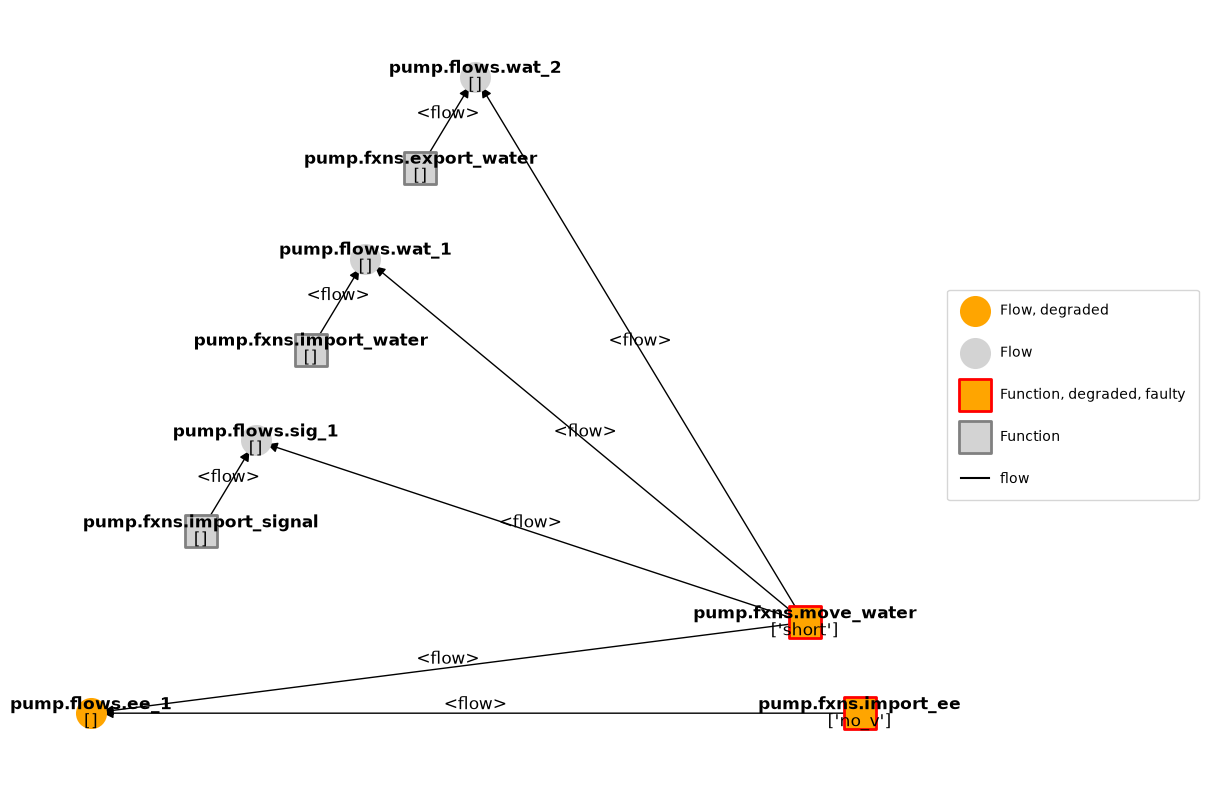

In [20]:
faultgraph = endresults.get_faulty().tend.graph
fig = faultgraph.draw()

In [21]:
faultgraph.g.nodes['pump.fxns.move_water']

{'nodetype': 'Function',
 'classname': 'MoveWat',
 't': MoveWatTime(time=55.0, t_ind=55, timers={'pressure_limit': Timer pressure_limit: mode= standby, time= 0.0}, use_local=True, dt=1.0, executed_static=True, executed_dynamic=False, executing=False),
 's': MoveWatStates(eff=0.0),
 'm': MoveWatMode(faults={'short'}, sub_faults=False),
 'indicators': [],
 'degraded': True,
 'faulty': True}

As can be seen, at the final t, the short causes a degraded flow of electricity as well as a fault in the Import EE function. 

**However**, we would imagine that the short would cause the water to stop moving also--so why is it not red?

The answer is that by default the degradations shown in the graph are shown at the **final time**, which is the same both for the failed model and the nominal model, since the pump is switched "off." In this case we might be more interested in looking at how the graph looks in operation, rather than at the end.

We can do that that in two ways:
- by specifying a different time to fetch the graph from (e.g., `to_return={10:'graph'}`, or
- by reconstructing the based on the history of the plot, as shown below:

In [22]:
mg = FunctionArchitectureGraph(mdl)

To do this, we first need to track more states than have been specified to track in the model. The easiest way to do this is to set `track='all'`.

In [23]:
endresults, mdlhist_full=propagate.one_fault(mdl, 'move_water', 'short', time=10, track='all',
                                        to_return=['graph','classify','endfaults'])

We can then plot the state at any time in the history using `mg.draw_from`.

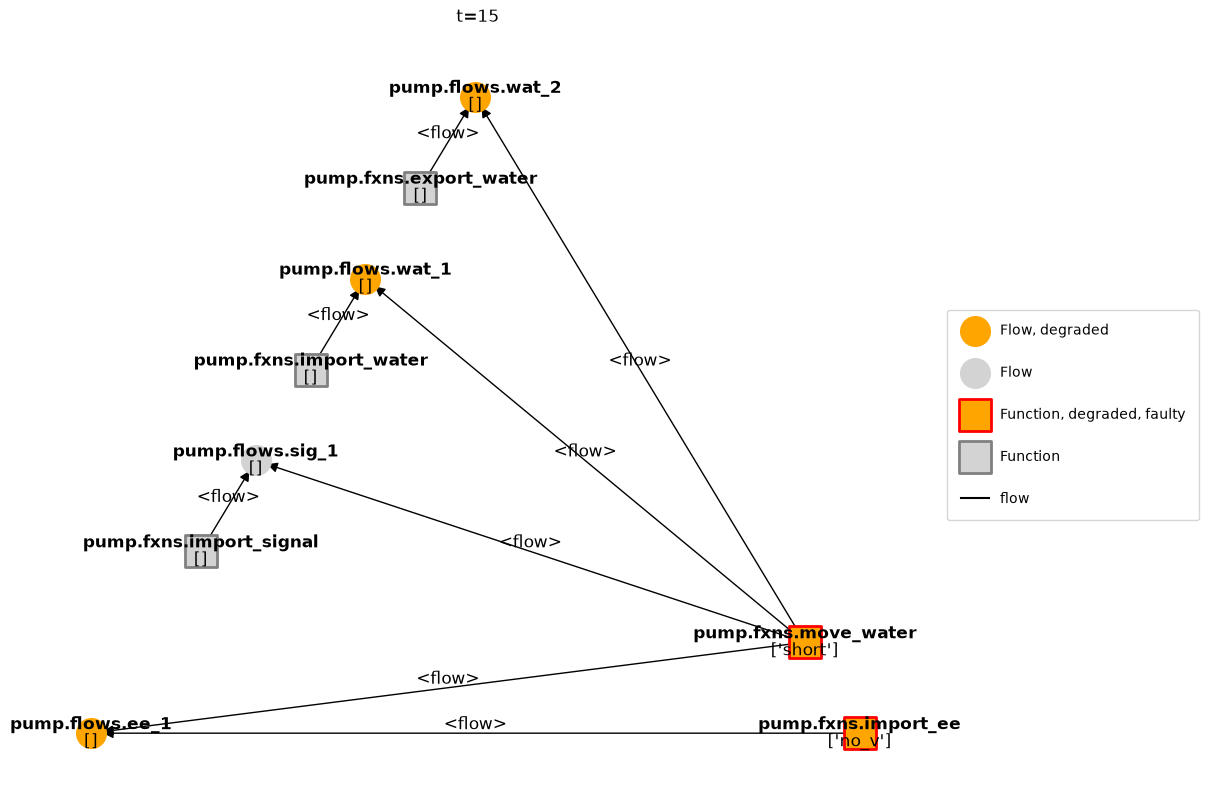

In [24]:
fig, ax = mg.draw_from(15, mdlhist_full)

As shown, this version has the degradation of the water, since at this time the off-nominal state is different from the nominal (no flow).

We can view an animation over time using:

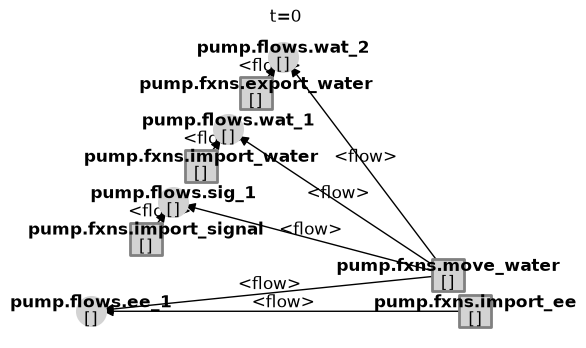

In [25]:
from IPython.display import HTML
ani = mg.animate(mdlhist_full)
HTML(ani.to_jshtml())

Note that if only a partial history is given, only partial results will be displayed (see below).

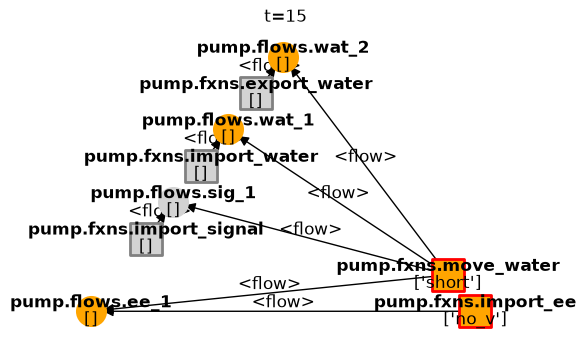

In [26]:
fig, ax = mg.draw_from(15, mdlhist, figsize=(6,4), withlegend=False)

We can also plot the states of this against the nominal run using:

In [27]:
mdlhist

nominal.i.finished:            array(56)
nominal.i.on:                  array(56)
nominal.m.sub_faults:          array(56)
nominal.time:                  array(56)
nominal.flows.ee_1.s.current:  array(56)
nominal.flows.ee_1.s.voltage:  array(56)
nominal.flows.sig_1.s.power:   array(56)
nominal.flows.wat_1.s.flowrate: array(56)
nominal.flows.wat_1.s.pressure: array(56)
nominal.flows.wat_1.s.area:    array(56)
nominal.flows.wat_1.s.level:   array(56)
nominal.flows.wat_2.s.flowrate: array(56)
nominal.flows.wat_2.s.pressure: array(56)
nominal.flows.wat_2.s.area:    array(56)
nominal.flows.wat_2.s.level:   array(56)
nominal.fxns.import_ee.s.effstate: array(56)
nominal.fxns.import_ee.m.faults.inf_v: array(56)
nominal.fxns.import_ee.m.faults.no_v: array(56)
nominal.fxns.import_ee.m.sub_faults: array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import_water.m.sub_faults: array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import

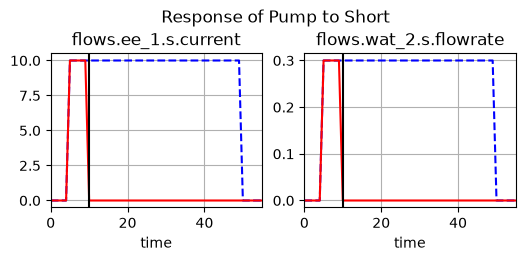

In [28]:
fig, axs = mdlhist.plot_line('flows.ee_1.s.current', 'flows.wat_2.s.flowrate', 
                             title="Response of Pump to Short", time_slice=10, legend_loc=False, title_padding=0.1)

As you can see, the system begins nominal until the fault is injected at $t=10$. At this moment, not only are the electrical energy flows degraded, the flow of water is degraded also. However, at $t=55$ when the system is supposed to be turned off, this flow of water is no longer "degraded" because it is in the same state as the nominal system.

We can look at a table of to see more precisely what happened (and export, if needed). Note that we need to give the plotting function the mode ('short') and the time for it to plot properly.

In [29]:
mdlhist.as_table()

,nominal.i.finished,nominal.i.on,nominal.m.sub_faults,nominal.time,nominal.flows.ee_1.s.current,...,move_water_short_t10.fxns.move_water.m.sub_faults,move_water_short_t10.fxns.move_water.t.pressure_limit.time,move_water_short_t10.fxns.move_water.t.pressure_limit.mode,move_water_short_t10.fxns.export_water.m.faults.block,move_water_short_t10.fxns.export_water.m.sub_faults
0,False,False,False,0.0,0.0,...,False,0.0,standby,False,False
1,False,False,False,1.0,0.0,...,False,0.0,standby,False,False
2,False,False,False,2.0,0.0,...,False,0.0,standby,False,False
3,False,False,False,3.0,0.0,...,False,0.0,standby,False,False
4,False,False,False,4.0,0.0,...,False,0.0,standby,False,False
5,False,True,False,5.0,10.0,...,False,0.0,standby,False,False
6,False,True,False,6.0,10.0,...,False,0.0,standby,False,False
7,False,True,False,7.0,10.0,...,False,0.0,standby,False,False
8,False,True,False,8.0,10.0,...,False,0.0,standby,False,False
9,False,True,False,9.0,10.0,...,False,0.0,standby,False,False


Here we can see that the short dropped the voltage to zero, (this was because an open circuit resulted in the Import EE function), causing the water to stop flowing. Below, we use the processed model history to show the faults and *degradation* of states over time. In this case, 1 means nominal while 0 means degraded.

In [30]:
deghist = mdlhist_full.get_degraded_hist(*mdl.fxns, *mdl.flows)

In [31]:
deghist.as_table()[:20]

,import_ee,import_water,import_signal,move_water,export_water,...,sig_1,wat_1,wat_2,total,time
0,False,False,False,False,False,...,False,False,False,0,0.0
1,False,False,False,False,False,...,False,False,False,0,1.0
2,False,False,False,False,False,...,False,False,False,0,2.0
3,False,False,False,False,False,...,False,False,False,0,3.0
4,False,False,False,False,False,...,False,False,False,0,4.0
5,False,False,False,False,False,...,False,False,False,0,5.0
6,False,False,False,False,False,...,False,False,False,0,6.0
7,False,False,False,False,False,...,False,False,False,0,7.0
8,False,False,False,False,False,...,False,False,False,0,8.0
9,False,False,False,False,False,...,False,False,False,0,9.0


We can also look at the faults over time...

In [32]:
faulthist = mdlhist_full.get_faulty_hist(*mdl.fxns)
faulthist.as_table()[0:20]

,import_ee,import_water,import_signal,move_water,export_water,total,time
0,False,False,False,False,False,0,0.0
1,False,False,False,False,False,0,1.0
2,False,False,False,False,False,0,2.0
3,False,False,False,False,False,0,3.0
4,False,False,False,False,False,0,4.0
5,False,False,False,False,False,0,5.0
6,False,False,False,False,False,0,6.0
7,False,False,False,False,False,0,7.0
8,False,False,False,False,False,0,8.0
9,False,False,False,False,False,0,9.0


We can also look at statistics of degradation over time using:

In [33]:
summ = mdlhist_full.get_fault_degradation_summary(*mdl.fxns, *mdl.flows)
summ.has_faults

['import_ee', 'move_water']

In [34]:
summ.degraded

['import_ee', 'move_water', 'ee_1', 'wat_1', 'wat_2']

#### Blockage Fault

We can also look at other faults. The results below are for a blockage of the pipe. In this case we're only interested in the effect on the water going through, so only those flows are tracked.

In [35]:
endresults2, mdlhist2=propagate.one_fault(mdl, 'export_water', 'block', 
                                          time=10, to_return=['classify', 'graph', 'endfaults'])
summ = mdlhist_full.get_fault_degradation_summary(*mdl.fxns, *mdl.flows)

In [36]:
summ.has_faults

['import_ee', 'move_water']

In [37]:
summ.degraded

['import_ee', 'move_water', 'ee_1', 'wat_1', 'wat_2']

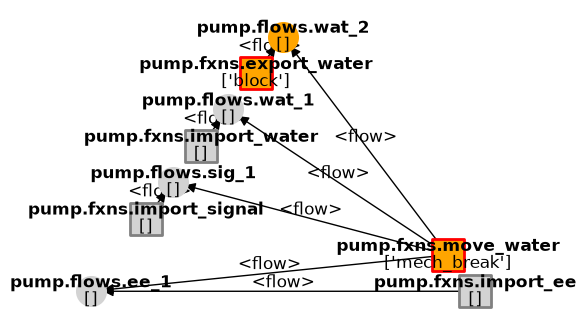

In [38]:
fig, ax = endresults2.faulty.tend.graph.draw(figsize=(6,4), withlegend=False)

In [39]:
mdlhist

nominal.i.finished:            array(56)
nominal.i.on:                  array(56)
nominal.m.sub_faults:          array(56)
nominal.time:                  array(56)
nominal.flows.ee_1.s.current:  array(56)
nominal.flows.ee_1.s.voltage:  array(56)
nominal.flows.sig_1.s.power:   array(56)
nominal.flows.wat_1.s.flowrate: array(56)
nominal.flows.wat_1.s.pressure: array(56)
nominal.flows.wat_1.s.area:    array(56)
nominal.flows.wat_1.s.level:   array(56)
nominal.flows.wat_2.s.flowrate: array(56)
nominal.flows.wat_2.s.pressure: array(56)
nominal.flows.wat_2.s.area:    array(56)
nominal.flows.wat_2.s.level:   array(56)
nominal.fxns.import_ee.s.effstate: array(56)
nominal.fxns.import_ee.m.faults.inf_v: array(56)
nominal.fxns.import_ee.m.faults.no_v: array(56)
nominal.fxns.import_ee.m.sub_faults: array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import_water.m.sub_faults: array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import

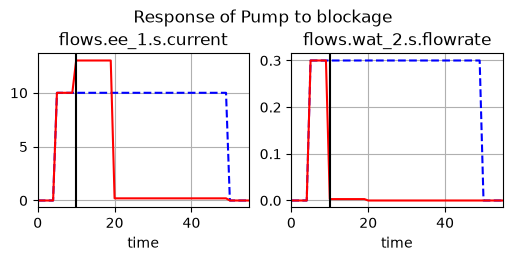

In [40]:
fig, axs = mdlhist2.plot_line('flows.ee_1.s.current', 'flows.wat_2.s.flowrate',
                              title = 'Response of Pump to blockage', time_slice=10, legend_loc=False, title_padding=0.1)

### Visualization of resilience metrics
We can also use the processed time history to now make visualizations of the resilience of the system over time. 

Here we calculate the percent time the simulation was decraded over the simulation interval:

In [41]:
fxns_and_flows = [*mdl.get_roles_as_dict("fxn", "flow", with_prefix=True)]
deghist = mdlhist_full.get_degraded_hist(*fxns_and_flows)
exp = deghist.get_metrics()

In [42]:
exp

fxns.import_ee:                 0.821429
fxns.import_water:                   0.0
fxns.import_signal:                  0.0
fxns.move_water:                0.821429
fxns.export_water:                   0.0
flows.ee_1:                     0.821429
flows.sig_1:                         0.0
flows.wat_1:                    0.714286
flows.wat_2:                    0.714286
total:                          3.892857
time:                               27.5

These metrics (and others like them) can then be overlayed as a heatmap using `set_heatmap`.

(<Figure size 1200x1000 with 1 Axes>, <Axes: >)

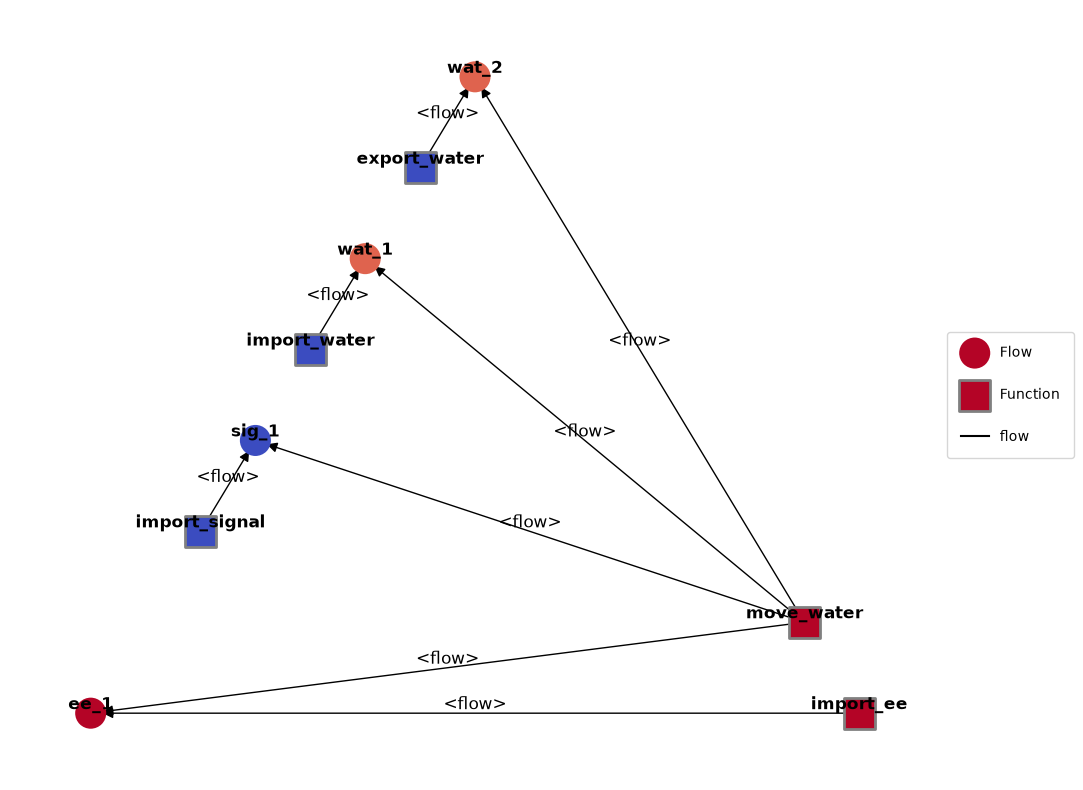

In [43]:
mg = FunctionArchitectureGraph(mdl)
mg.set_heatmap({mdl.name+"."+k: v for k, v in exp.items()})
mg.draw()

Network metrics can also be overlaid on the graphs:

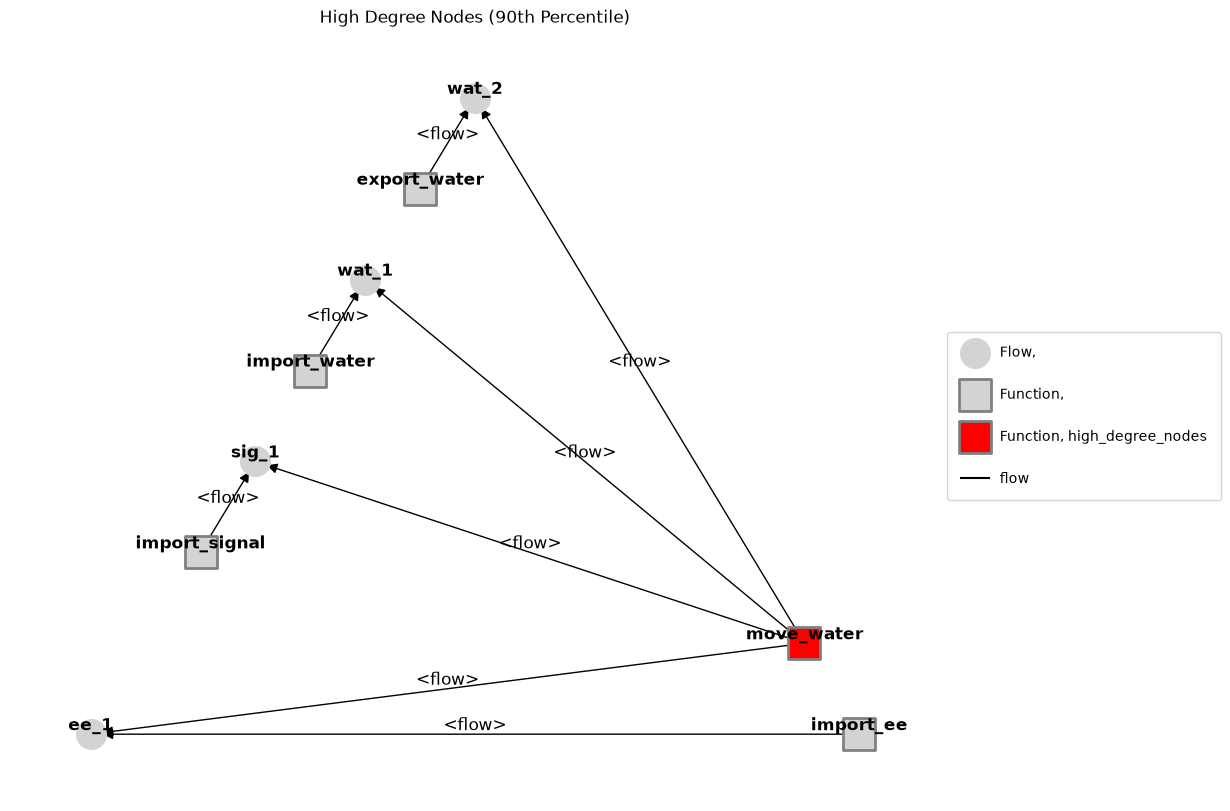

In [44]:
mg = FunctionArchitectureGraph(mdl)
fig, ax = mg.plot_high_degree_nodes()

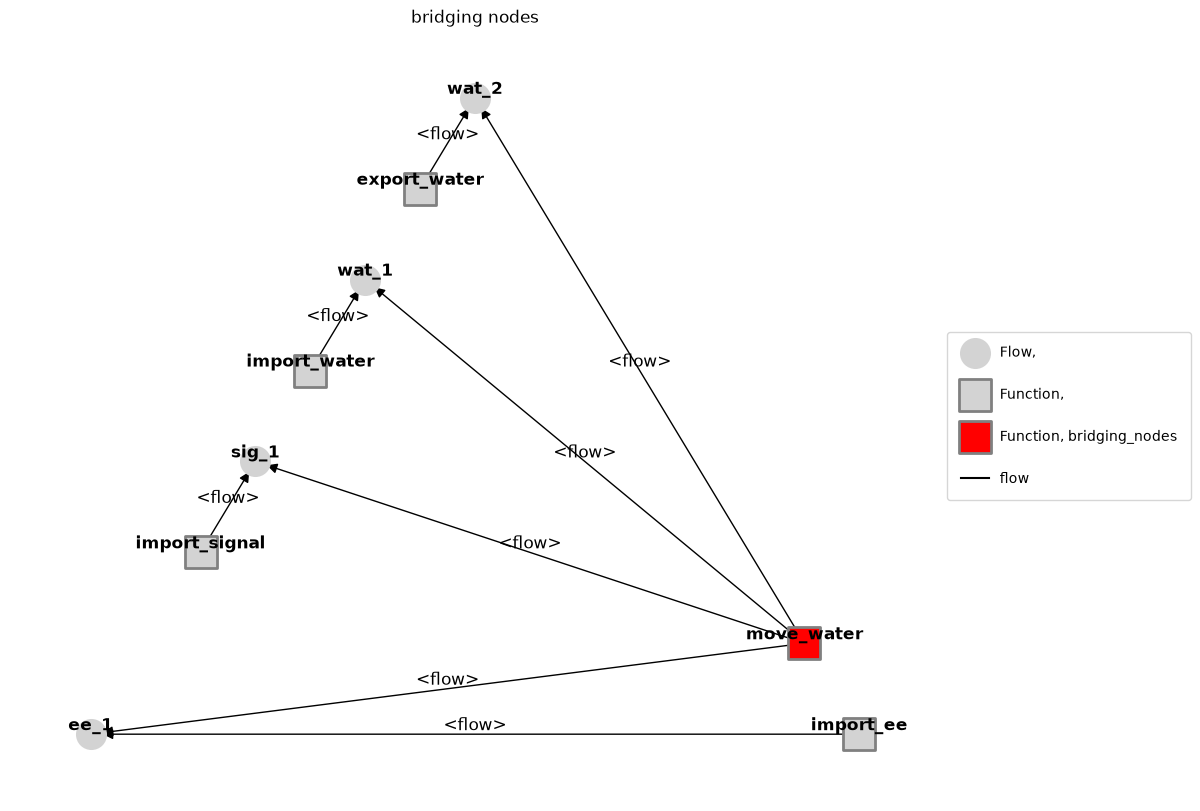

In [45]:
mg = FunctionArchitectureGraph(mdl)
fig, ax = mg.plot_bridging_nodes()

### Running a List of Faults
Finally, to get the results of all of the single-fault scenarios defined in the model, we can run them all at once using the `single_faults()` function. Note that this will propagate faults based on the times vector put in the model it will propogate the faults at the begining, end, and at t=15 and t=15. This function only takes in the model mdl and outputs two similar kinds of output--resultsdict (the results in a python dictionary) and resultstab (the results in a nice tabular form). 

Note that the rates provide for this table do not use the opportunity vector information, instead using the assumption that the fault scenario has the rate provided over the entire simulation.

See below:

In [46]:
results, mdlhists=propagate.single_faults(mdl, staged=True, track="all")

SCENARIOS COMPLETE: 100%|██████████| 8/8 [00:00<00:00, 17.09it/s]


We can visualize the metrics for each scenario using `Result.create_simple_fmea`

In [47]:
results.create_simple_fmea()

,rate,cost,expected_cost
nominal,1.000000e+00,0.0,0.00
pump_fxns_import_ee_inf_v_t0p0,0.000000e+00,25125.0,0.00
pump_fxns_import_ee_no_v_t0p0,0.000000e+00,20125.0,0.00
pump_fxns_import_water_less_wat_t0p0,1.000000e-05,5062.5,5062.50
pump_fxns_import_water_no_wat_t0p0,1.000000e-05,11125.0,11125.00
pump_fxns_import_signal_no_sig_t0p0,1.500000e-06,20125.0,3018.75
pump_fxns_move_water_mech_break_t0p0,6.000000e-07,15125.0,907.50
pump_fxns_move_water_short_t0p0,1.500000e-05,30125.0,45187.50
pump_fxns_export_water_block_t0p0,1.500000e-05,20102.5,30153.75


We can see corresponding degradations using `tabulate.result_summary.fmea()`

In [48]:
fullfmea = an.tabulate.result_summary_fmea(results, mdlhists, *mdl.fxns, *mdl.flows)
fullfmea[:10]

,degraded,faulty,rate,cost,expected_cost
nominal,[],[],1.0,0.0,0.0
pump_fxns_import_ee_inf_v_t0p0,"['import_ee', 'ee_1', 'wat_1', 'wat_2']",['import_ee'],0.0,25125.0,0.0
pump_fxns_import_ee_no_v_t0p0,"['import_ee', 'ee_1', 'wat_1', 'wat_2']",['import_ee'],0.0,20125.0,0.0
pump_fxns_import_water_less_wat_t0p0,"['import_water', 'ee_1', 'wat_1', 'wat_2']",['import_water'],0.00001,5062.5,5062.5
pump_fxns_import_water_no_wat_t0p0,"['import_water', 'ee_1', 'wat_1', 'wat_2']",['import_water'],0.00001,11125.0,11125.0
pump_fxns_import_signal_no_sig_t0p0,"['import_signal', 'ee_1', 'sig_1', 'wat_1', 'w...",['import_signal'],0.000002,20125.0,3018.75
pump_fxns_move_water_mech_break_t0p0,"['move_water', 'ee_1', 'wat_1', 'wat_2']",['move_water'],0.000001,15125.0,907.5
pump_fxns_move_water_short_t0p0,"['import_ee', 'move_water', 'ee_1', 'wat_1', '...","['import_ee', 'move_water']",0.000015,30125.0,45187.5
pump_fxns_export_water_block_t0p0,"['move_water', 'export_water', 'ee_1', 'wat_1'...","['move_water', 'export_water']",0.000015,20102.5,30153.75


### Running a Fault Sampling Approach
Note that only gives accurate results for costs and fault responses--in order to get an accurate idea of *expected cost*, we instead run a FaultSample or SampleApproach, which develops an underlying probability model for faults. See below.

In [49]:
from fmdtools.sim.sample import FaultDomain, FaultSample

fd = FaultDomain(mdl)
fd.add_all()
fd

FaultDomain with faults:
 -('pump.fxns.import_ee', 'inf_v')
 -('pump.fxns.import_ee', 'no_v')
 -('pump.fxns.import_water', 'less_wat')
 -('pump.fxns.import_water', 'no_wat')
 -('pump.fxns.import_signal', 'no_sig')
 -('pump.fxns.move_water', 'mech_break')
 -('pump.fxns.move_water', 'short')
 -('pump.fxns.export_water', 'block')

In [50]:
from fmdtools.analyze.phases import PhaseMap
fs = FaultSample(fd, phasemap=PhaseMap(mdl.sp.phases))
fs.add_fault_phases()
fs

FaultSample of scenarios: 
 - pump_fxns_import_ee_inf_v_t2p0
 - pump_fxns_import_ee_no_v_t2p0
 - pump_fxns_import_water_less_wat_t2p0
 - pump_fxns_import_water_no_wat_t2p0
 - pump_fxns_import_signal_no_sig_t2p0
 - pump_fxns_move_water_mech_break_t2p0
 - pump_fxns_move_water_short_t2p0
 - pump_fxns_export_water_block_t2p0
 - pump_fxns_import_ee_inf_v_t27p0
 - pump_fxns_import_ee_no_v_t27p0
 - ... (24 total)

In [51]:
results, mdlhists=propagate.fault_sample(mdl, fs, staged=True, track="all")
simplefmea = results.create_simple_fmea() #note the costs are the same, but the rates and expected costs are not
simplefmea[:5]

SCENARIOS COMPLETE: 100%|██████████| 24/24 [00:00<00:00, 30.85it/s]


,rate,cost,expected_cost
nominal,1.00000,0.0,0.0
pump_fxns_import_ee_inf_v_t2p0,0.00000,25125.0,0.0
pump_fxns_import_ee_no_v_t2p0,0.00000,20125.0,0.0
pump_fxns_import_water_less_wat_t2p0,0.00001,5062.5,5062.5
pump_fxns_import_water_no_wat_t2p0,0.00001,11125.0,11125.0


We can now summarize the risks of faults over the operational phases and overall using the `FMEA` class:

In [52]:
phasefmea = an.tabulate.FMEA(results, fs, group_by=('obj', 'fault', 'phase'))
phasefmea.as_table()

average_scenario_rate  sum_cost  expected_cost
pump.fxns.move_water    short      start               0.000015   30125.0       0.451875
pump.fxns.export_water  block      start               0.000015   20102.5       0.301538
pump.fxns.move_water    short      on                  0.000010   25175.0       0.251750
pump.fxns.export_water  block      on                  0.000010   15152.5       0.151525
pump.fxns.import_ee     no_v       on                  0.000008   15175.0       0.121400
pump.fxns.import_water  no_wat     start               0.000010   11125.0       0.111250
pump.fxns.move_water    short      end                 0.000010   10000.0       0.100000
                        mech_break on                  0.000007   10175.0       0.073260
pump.fxns.import_water  no_wat     on                  0.000010    6175.0       0.061750
                        less_wat   start               0.000010    5062.5       0.050625
pump.fxns.export_water  block      end                 0.000010    5000.0       0.050000
pump.fxns.import_ee     inf_v      on                  0.000002   20175.0       0.040350
pump.fxns.import_signal no_sig     start               0.000002   20125.0       0.030188
pump.fxns.import_water  less_wat   on                  0.000010    2587.5       0.025875
pump.fxns.import_signal no_sig     on                  0.000001   15175.0       0.015175
                                   end                 0.000001   10000.0       0.010000
pump.fxns.import_water  no_wat     end                 0.000010    1000.0       0.010000
pump.fxns.move_water    mech_break start               0.000001   15125.0       0.009075
                                   end                 0.000001    5000.0       0.003000
pump.fxns.import_ee     no_v       start               0.000000   20125.0       0.000000
                        inf_v      start               0.000000   25125.0       0.000000
                        no_v       end                 0.000000   10000.0       0.000000
pump.fxns.import_water  less_wat   end                 0.000010       0.0       0.000000
pump.fxns.import_ee     inf_v      end                 0.000000    5000.0       0.000000

In [53]:
summfmea = an.tabulate.FMEA(results, fs)
summfmea.as_table()

,,average_scenario_rate,sum_cost,expected_cost
pump.fxns.move_water,short,0.000012,65300.0,0.803625
pump.fxns.export_water,block,0.000012,40255.0,0.503063
pump.fxns.import_water,no_wat,0.000010,18300.0,0.183000
pump.fxns.import_ee,no_v,0.000003,45300.0,0.121400
pump.fxns.move_water,mech_break,0.000003,30300.0,0.085335
pump.fxns.import_water,less_wat,0.000010,7650.0,0.076500
pump.fxns.import_signal,no_sig,0.000001,45300.0,0.055363
pump.fxns.import_ee,inf_v,0.000001,50300.0,0.040350


#### History visualization

We can further overlay expected resilience metrics on the model over fault scenarios using various methods provided with `History` and `Result`.

Below we get the expected values of the history values:

In [54]:
hist_expected = mdlhists.get_expected(app=fs, with_nominal=True)

Next we get the expected degradations:

In [55]:
hist_expected

time:                          array(56)
flows.ee_1.s.current:          array(56)
flows.ee_1.s.voltage:          array(56)
flows.sig_1.s.power:           array(56)
flows.wat_1.s.flowrate:        array(56)
flows.wat_1.s.pressure:        array(56)
flows.wat_1.s.area:            array(56)
flows.wat_1.s.level:           array(56)
flows.wat_2.s.flowrate:        array(56)
flows.wat_2.s.pressure:        array(56)
flows.wat_2.s.area:            array(56)
flows.wat_2.s.level:           array(56)
fxns.import_ee.s.effstate:     array(56)
fxns.move_water.s.eff:         array(56)
fxns.move_water.t.pressure_limit.time: array(56)

In [56]:
deg=hist_expected.get_degraded_hist(*fxns_and_flows, nomhist=mdlhists.nominal)

In [57]:
deg

fxns.import_ee:                array(56)
fxns.move_water:               array(56)
flows.ee_1:                    array(56)
flows.sig_1:                   array(56)
flows.wat_1:                   array(56)
flows.wat_2:                   array(56)
total:                         array(56)
time:                          array(56)

In [58]:
import numpy as np
heatmap = deg.get_metrics(metric=np.mean)
heatmap


fxns.import_ee:                      0.0
fxns.move_water:                     0.0
flows.ee_1:                          0.0
flows.sig_1:                         0.0
flows.wat_1:                    0.803571
flows.wat_2:                    0.803571
total:                          1.607143
time:                               27.5

These metrics can in turn be overlayed on the graph using `set_heatmap`.

(<Figure size 1200x1000 with 1 Axes>, <Axes: >)

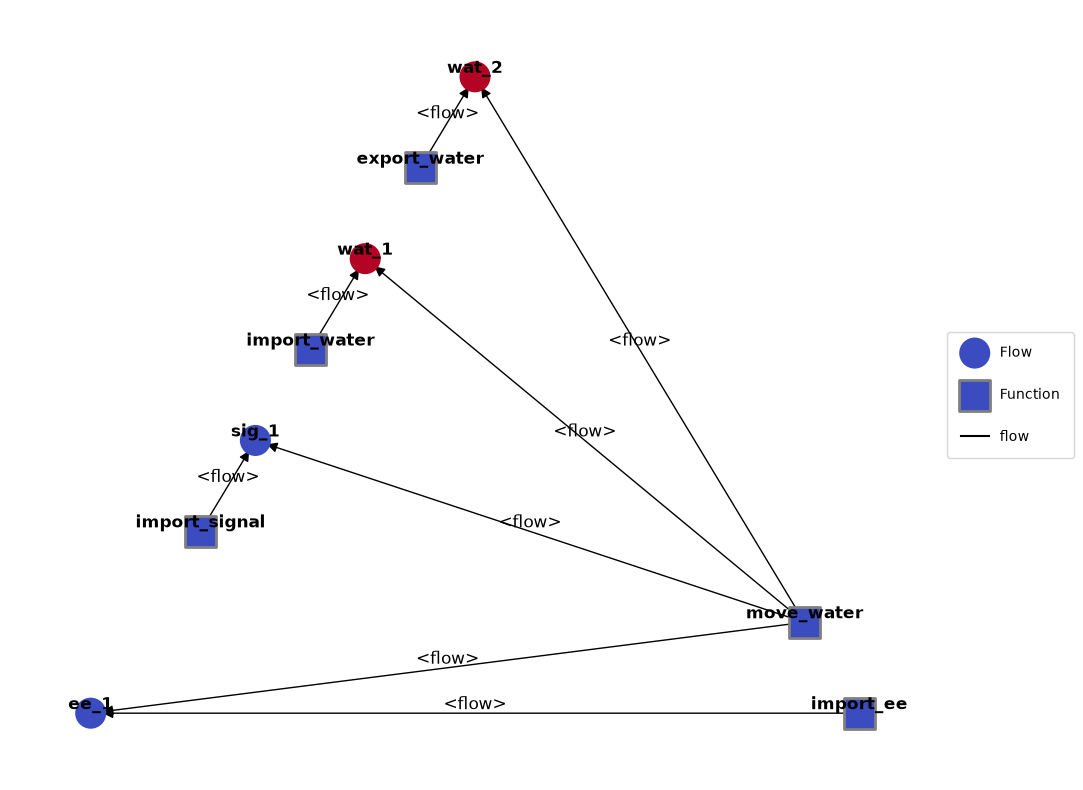

In [59]:
from fmdtools.define.architecture.function import FunctionArchitectureGraph
mg = FunctionArchitectureGraph(mdl)
hm = {}
for k, v in heatmap.items():
    if k not in ['total', 'time']:
        hm['pump.'+k] = v
mg.set_heatmap(hm)
mg.draw()

## Save/Load

In detailed simulations, running a lot of computational simulations can take a considerable amount of time. As a result, it becomes impractical to run a new simulation every time one wishes to analyse its data. Results from fmdtools simulations (results or histories) can be saved as npz, csv, or json files in this instance using either:
- `Result.save` or `History.save` or 
- passing a save_args dictionary to the respective propagate functions (e.g., {'classify':{'filename':'file.pkl','overwrite':True})

and then loaded using:
- `Result.load` or `History.load`

In [60]:
mdlhists

nominal.i.finished:            array(56)
nominal.i.on:                  array(56)
nominal.m.sub_faults:          array(56)
nominal.time:                  array(56)
nominal.flows.ee_1.s.current:  array(56)
nominal.flows.ee_1.s.voltage:  array(56)
nominal.flows.sig_1.s.power:   array(56)
nominal.flows.wat_1.s.flowrate: array(56)
nominal.flows.wat_1.s.pressure: array(56)
nominal.flows.wat_1.s.area:    array(56)
nominal.flows.wat_1.s.level:   array(56)
nominal.flows.wat_2.s.flowrate: array(56)
nominal.flows.wat_2.s.pressure: array(56)
nominal.flows.wat_2.s.area:    array(56)
nominal.flows.wat_2.s.level:   array(56)
nominal.fxns.import_ee.s.effstate: array(56)
nominal.fxns.import_ee.m.faults.inf_v: array(56)
nominal.fxns.import_ee.m.faults.no_v: array(56)
nominal.fxns.import_ee.m.sub_faults: array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import_water.m.sub_faults: array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import

This saves a history to a file:

In [61]:
mdlhists.save("outputs_demo_fault_analysis/example_mdlhist.npz", overwrite=True)

File already exists: outputs_demo_fault_analysis/example_mdlhist.npz, writing anyway...


And this loads this history:

In [62]:
mdlhists_saved  = an.history.History.load("outputs_demo_fault_analysis/example_mdlhist.npz")

In [63]:
mdlhists_saved 

nominal.i.finished:            array(56)
nominal.i.on:                  array(56)
nominal.m.sub_faults:          array(56)
nominal.time:                  array(56)
nominal.flows.ee_1.s.current:  array(56)
nominal.flows.ee_1.s.voltage:  array(56)
nominal.flows.sig_1.s.power:   array(56)
nominal.flows.wat_1.s.flowrate: array(56)
nominal.flows.wat_1.s.pressure: array(56)
nominal.flows.wat_1.s.area:    array(56)
nominal.flows.wat_1.s.level:   array(56)
nominal.flows.wat_2.s.flowrate: array(56)
nominal.flows.wat_2.s.pressure: array(56)
nominal.flows.wat_2.s.area:    array(56)
nominal.flows.wat_2.s.level:   array(56)
nominal.fxns.import_ee.s.effstate: array(56)
nominal.fxns.import_ee.m.faults.inf_v: array(56)
nominal.fxns.import_ee.m.faults.no_v: array(56)
nominal.fxns.import_ee.m.sub_faults: array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import_water.m.sub_faults: array(56)
nominal.fxns.import_           array(56)
nominal.fxns.import

Note that there are different trade-offs to using different file formats:
- `npz` is the serialization format provided in numpy, which is fast but not human readable
- `csv` outputs as comma separated values, which are slower and less robust (in terms of data types), but are human-readable and can be opened in a spreadsheet software like excel.
- `json` is similar to csv, but is less human readable.